In [13]:
import random
import time
from queue import PriorityQueue
import matplotlib
import numpy as np
import rasterio as rio
import cbor2
from datetime import timedelta
from astropy.time import Time
import matplotlib.pyplot as plt

matplotlib.use("tkagg")
import pandas as pd

class Graph(object):
    def __init__(self, vertices, edges, weights):
        self.vertices = vertices
        self.edges = edges
        self.weights = weights
        self.in_adj = list()
        self.out_adj = list()

        for v in vertices:
            self.in_adj.append(list())
            self.out_adj.append(list())

        for e in edges:
            self.in_adj[e[1]].append(e)
            self.out_adj[e[0]].append(e)

class Pair(object):
    def __init__(self, tau, g, v):
        self.tau = tau
        self.g = g
        self.v = v

    def __lt__(self, other):
        return self.g[self.tau[self.v]] < other.g[other.tau[other.v]]

    def __str__(self):
        return str((self.v, self.tau[self.v], self.g[self.tau[self.v]]))

    def __repr__(self):
        return str((self.v, self.tau[self.v], self.g[self.tau[self.v]]))

def print_queue(Q):
    print("Current queue state:")
    for item in Q.queue:
        print(item)

def time_refinement(Gt, vs, ve, T):
    ts = T[0]
    te = T[-1]
    g = {v: {t: np.inf for t in T} for v in Gt.vertices}
    g[vs][ts] = ts
    tau = {v: ts for v in Gt.vertices}
    
    Q = PriorityQueue()
    Q.put(Pair(tau, g[vs], vs))
    
    while not Q.empty():
        pair_i = Q.get()
        v_i = pair_i.v
        tau_i = tau[v_i]
        
        if tau_i >= te:
            continue
        
        for e in Gt.out_adj[v_i]:
            v_j = e[1]
            for t in T:
                if t < tau_i:
                    continue

                g_i_t = g[v_i][t]
                
                # Correctly call the weight function with the current time `t` from T
                weight = Gt.weights[e](t)

                new_g = g_i_t + weight
                if new_g < g[v_j][t]:
                    g[v_j][t] = new_g
                    Q.put(Pair(tau, g[v_j], v_j))
                    tau[v_j] = t
    
    return g
    
def path_selector(Gt, g, vs, ve, t_star):
    path = []
    current_node = ve
    total_traverse_time = 0  # Initialize total traverse time
    while current_node != vs:
        for e in Gt.in_adj[current_node]:
            if g[e[0]][t_star] + Gt.weights[e](t_star) == g[current_node][t_star]:
                traverse_time = Gt.weights[e](t_star)  # Calculate time for this edge
                total_traverse_time += traverse_time
                path.append((e[0], e[1]))
                current_node = e[0]
                break
    path = list(reversed(path))
    return path, total_traverse_time

def algorithm(Gt, vs, ve, T):
    g = time_refinement(Gt, vs, ve, T)
    if any(not np.isinf(g[ve][t]) for t in T):
        t_star = min(T, key=lambda t: g[ve][t] - t)
        p_star, total_traverse_time = path_selector(Gt, g, vs, ve, t_star)
        return t_star, p_star, total_traverse_time
    else:
        return None

def generate_weight_function(slope_dem, roots, node1, node2, t):
    time = t*24*60*60
    t = Time(time,format = 'cxcsec',scale='tdb')
    t = t.cxcsec
        # node2 should be a tuple representing the coordinates (i, j) of a node
    i = node2[0] * slope_dem.shape[1] + node2[1]  # Convert the node coordinates to a unique index
    node2_str = str(i)  # Convert the index to a string to match the keys in roots
    for sunrises in roots[str(i)]['sunrises']:
        for sunsets in roots[str(i)]['sunsets']:
            if t >= (sunrises * 24 * 60 * 60) and t < (sunsets * 24 * 60 * 60):
                illumination = True
            elif sunrises > sunsets and t < (sunsets * 24 * 60 * 60):
                illumination = True
            elif sunrises == [] and sunsets == []:
                illumination = False
                sunrise = 10000000 * 24 * 60 * 60
            elif (sunrises * 24 * 60 * 60) < t and (sunsets * 24 * 60 * 60) < t:
                illumination = False
                sunrise = 10000000 * 24 * 60 * 60
            else:
                illumination = False
                sunrise = sunrises * 24 * 60 * 60

    def weight_function():
        if illumination == True:
            if node1[0] != node2[0] and node1[1] != node2[1]:
                x = np.sqrt(2)
            else:
                x = 1
            speed1 = 0.025 - (0.001 * slope_dem[node1[0], node1[1]])
            speed2 = 0.025 - (0.001 * slope_dem[node2[0], node2[1]])
            speed = (speed1 + speed2) / 2
            if speed1 < 0.01 or speed2 < 0.01:
                speed = 0.000001
            time_s = float(x / speed)
        else:
            if node1[0] != node2[0] and node1[1] != node2[1]:
                x = np.sqrt(2)
            else:
                x = 1
            speed1 = 0.025 - (0.001 * slope_dem[node1[0], node1[1]])
            speed2 = 0.025 - (0.001 * slope_dem[node2[0], node2[1]])
            speed = (speed1 + speed2) / 2
            if speed1 < 0.01 or speed2 < 0.01:
                speed = 0.000001
            time_s = float(x / speed) + (sunrise - t)
        return time_s  # Ensure the time cost is positive

    return weight_function

def generate_graph_with_weights(slope_dem, roots, T):
    rows, cols = slope_dem.shape
    
    vertices = {}
    edges = []
    weights = {}
    
    # Create a mapping for vertices
    vertex_id = 0
    for i in range(rows):
        for j in range(cols):
            vertices[(i, j)] = vertex_id
            vertex_id += 1
    
    # Add edges and compute weights
    for i in range(rows):
        for j in range(cols):
            current_node = (i, j)
            current_vertex = vertices[current_node]
            
            # Define neighbors (8-connectivity)
            neighbors = [
                (i-1, j-1), (i-1, j), (i-1, j+1),
                (i, j-1),           (i, j+1),
                (i+1, j-1), (i+1, j), (i+1, j+1)
            ]
            for neighbor in neighbors:
                ni, nj = neighbor
                if 0 <= ni < rows and 0 <= nj < cols:
                    neighbor_vertex = vertices[(ni, nj)]
                    edges.append((current_vertex, neighbor_vertex))
                    
                    # Generate a unique weight function for each edge based on time `t`
                    def dynamic_weight_function(t, current_node=current_node, neighbor_node=(ni, nj)):
                        return generate_weight_function(slope_dem, roots, current_node, neighbor_node, t)()
                    
                    # Assign the function to the weights with the current time value `t` passed from `T`
                    weights[(current_vertex, neighbor_vertex)] = dynamic_weight_function

    # Convert vertices to a list of vertex ids
    vertex_ids = list(vertices.values())
    
    return vertex_ids, edges, weights


def vertex_to_dem_coordinates(vertex_id, dem_shape):
    """Convert a vertex ID back to DEM coordinates."""
    rows, cols = dem_shape
    i = vertex_id // cols
    j = vertex_id % cols
    return (i, j)

def seconds_to_hhmmss(seconds):
    """Convert time in seconds to hh:mm:ss format."""
    return str(timedelta(seconds=int(seconds)))

def format_path(vertices, path, total_traverse_time, dem_shape, start_time):
    """Format the output path to show DEM coordinates and traverse time."""
    formatted_path = []
    current_time = start_time

    for start, end in path:
        start_coords = vertex_to_dem_coordinates(start, dem_shape)
        formatted_path.append(start_coords)
        # Assume time increment happens after each segment
        current_time += total_traverse_time / len(path)
    
    # Add the final end point
    end_coords = vertex_to_dem_coordinates(path[-1][1], dem_shape)
    formatted_path.append(end_coords)

    total_time_str = seconds_to_hhmmss(total_traverse_time)
    start_time_str = start_time
    
    return start_time_str,formatted_path,total_time_str


def generate_time_range(start, end, resolution):
    """Generate a time range with float resolution."""
    num_steps = int((end - start) / resolution) + 1
    return [start + i * resolution for i in range(num_steps)]

# Main execution section remains unchanged.
if __name__ == "__main__":
    # Define weight functions and graph parameters
    filename = 'data/dems/test_case_A.tif'
    illumination_filename = 'data/illumination/test_case_A.cbor'
    with rio.open(filename) as dataset:
        slope_dem = dataset.read(1) 
    with open(illumination_filename, "rb") as file: #ILLUMINATION DICT
        roots = cbor2.load(file)
    
    # Define the time range with float resolution
    T = generate_time_range(11000.49, 11001.0, 0.1)
    # Example start and end points
    start = (8, 1)  # Start vertex
    end = (1, 8)  # End vertex (change based on your vertex mapping)
    vs = (start[0] * slope_dem.shape[1]) + start[1]
    ve = (end[0] * slope_dem.shape[1]) + end[1]
    
    # Generate graph with weights
    vertices, edges, weights = generate_graph_with_weights(slope_dem, roots, T)
    Gt = Graph(vertices, edges, weights)
    
    start_time = time.time()
    result = algorithm(Gt, vs, ve, T)
    
    if result:
        t_star, p_star, total_traverse_time = result
        start_time_str,formatted_path,total_time_str = format_path(vertices, p_star, total_traverse_time, slope_dem.shape, t_star)
        print(f"Optimal Departure Time: {start_time_str}, Path Taken: {formatted_path}, Total Traverse Time: {total_time_str}")
    else:
        print("No valid path found.")
    
    print("Time elapsed:", time.time() - start_time)

Optimal Departure Time: 11000.49, Path Taken: [(8, 1), (7, 0), (6, 0), (5, 0), (4, 1), (4, 2), (3, 3), (2, 2), (2, 1), (1, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (1, 8)], Total Traverse Time: 0:13:15
Time elapsed: 1.7610926628112793


In [14]:
import random
import time
from queue import PriorityQueue
import matplotlib
import numpy as np
import rasterio as rio
import cbor2
from datetime import timedelta
from astropy.time import Time
import matplotlib.pyplot as plt

matplotlib.use("tkagg")
import pandas as pd

class Graph(object):
    def __init__(self, vertices, edges, weights):
        self.vertices = vertices
        self.edges = edges
        self.weights = weights
        self.in_adj = list()
        self.out_adj = list()

        for v in vertices:
            self.in_adj.append(list())
            self.out_adj.append(list())

        for e in edges:
            self.in_adj[e[1]].append(e)
            self.out_adj[e[0]].append(e)

class Pair(object):
    def __init__(self, tau, g, v):
        self.tau = tau
        self.g = g
        self.v = v

    def __lt__(self, other):
        return self.g[self.tau[self.v]] < other.g[other.tau[other.v]]

    def __str__(self):
        return str((self.v, self.tau[self.v], self.g[self.tau[self.v]]))

    def __repr__(self):
        return str((self.v, self.tau[self.v], self.g[self.tau[self.v]]))

def print_queue(Q):
    print("Current queue state:")
    for item in Q.queue:
        print(item)

def time_refinement(Gt, vs, ve, T):
    ts = T[0]
    te = T[-1]
    g = {v: {t: np.inf for t in T} for v in Gt.vertices}
    g[vs][ts] = ts
    tau = {v: ts for v in Gt.vertices}
    
    Q = PriorityQueue()
    Q.put(Pair(tau, g[vs], vs))
    
    while not Q.empty():
        pair_i = Q.get()
        v_i = pair_i.v
        tau_i = tau[v_i]
        
        if tau_i >= te:
            continue
        
        for e in Gt.out_adj[v_i]:
            v_j = e[1]
            for t in T:
                if t < tau_i:
                    continue

                g_i_t = g[v_i][t]
                
                # Correctly call the weight function with the current time `t` from T
                weight = Gt.weights[e](t)

                new_g = g_i_t + weight
                if new_g < g[v_j][t]:
                    g[v_j][t] = new_g
                    Q.put(Pair(tau, g[v_j], v_j))
                    tau[v_j] = t
    
    return g
    
def path_selector(Gt, g, vs, ve, t_star):
    path = []
    current_node = ve
    total_traverse_time = 0  # Initialize total traverse time
    while current_node != vs:
        for e in Gt.in_adj[current_node]:
            if g[e[0]][t_star] + Gt.weights[e](t_star) == g[current_node][t_star]:
                traverse_time = Gt.weights[e](t_star)  # Calculate time for this edge
                total_traverse_time += traverse_time
                path.append((e[0], e[1]))
                current_node = e[0]
                break
    path = list(reversed(path))
    return path, total_traverse_time

def algorithm(Gt, vs, ve, T, consider_wait_time):
    best_t_star = None
    best_p_star = None
    best_total_time = np.inf
    
    for t in T:
        g = time_refinement(Gt, vs, ve, [t])
        if not np.isinf(g[ve][t]):
            p_star, traverse_time = path_selector(Gt, g, vs, ve, t)
            
            # Calculate total time depending on the mode
            if consider_wait_time == False:
                total_time = t + traverse_time - T[0]
            else:
                total_time = traverse_time
            
            if total_time < best_total_time:
                best_total_time = total_time
                best_t_star = t
                best_p_star = p_star
    
    if best_t_star is not None:
        return best_t_star, best_p_star, best_total_time
    else:
        return None
    
def algorithm(Gt, vs, ve, T,consider_wait_time):
    g = time_refinement(Gt, vs, ve, T)
    if any(not np.isinf(g[ve][t]) for t in T):
        t_star = min(T, key=lambda t: g[ve][t] - t)
        p_star, total_traverse_time = path_selector(Gt, g, vs, ve, t_star)
        return t_star, p_star, total_traverse_time
    else:
        return None

#def generate_weight_function(slope_dem, roots, node1, node2, t):
    time = t * 24 * 60 * 60
    t = Time(time, format='cxcsec', scale='tdb')
    t = t.cxcsec
    i = node2[0] * slope_dem.shape[1] + node2[1]  # Convert the node coordinates to a unique index
    node2_str = str(i)  # Convert the index to a string to match the keys in roots
    for sunrises in roots[str(i)]['sunrises']:
        for sunsets in roots[str(i)]['sunsets']:
            if t >= (sunrises * 24 * 60 * 60) and t < (sunsets * 24 * 60 * 60):
                illumination = True
            elif sunrises > sunsets and t < (sunsets * 24 * 60 * 60):
                illumination = True
            elif sunrises == [] and sunsets == []:
                illumination = False
                sunrise = 10000000 * 24 * 60 * 60
            elif (sunrises * 24 * 60 * 60) < t and (sunsets * 24 * 60 * 60) < t:
                illumination = False
                sunrise = 10000000 * 24 * 60 * 60
            else:
                illumination = False
                sunrise = sunrises * 24 * 60 * 60

    def weight_function():
        if illumination == True:
            if node1[0] != node2[0] and node1[1] != node2[1]:
                x = np.sqrt(2)
            else:
                x = 1
            speed1 = 0.025 - (0.001 * slope_dem[node1[0], node1[1]])
            speed2 = 0.025 - (0.001 * slope_dem[node2[0], node2[1]])
            speed = (speed1 + speed2) / 2
            if speed1 < 0.01 or speed2 < 0.01:
                speed = 0.000001
            time_s = float(x / speed)
        else:
            if node1[0] != node2[0] and node1[1] != node2[1]:
                x = np.sqrt(2)
            else:
                x = 1
            speed1 = 0.025 - (0.001 * slope_dem[node1[0], node1[1]])
            speed2 = 0.025 - (0.001 * slope_dem[node2[0], node2[1]])
            speed = (speed1 + speed2) / 2
            if speed1 < 0.01 or speed2 < 0.01:
                speed = 0.000001
            time_s = float(x / speed) + (sunrise - t)
        return time_s  # Ensure the time cost is positive

    return weight_function


def generate_weight_function(slope_dem, roots, node1, node2, t):
    """
    Generate a weight function based on slope, illumination, and time.

    Args:
    - slope_dem: The slope DEM matrix.
    - roots: Illumination data.
    - node1, node2: Coordinates of the two nodes (start and end).
    - t: Current time in days.

    Returns:
    - A function that computes the travel time between node1 and node2.
    """
    time_in_days = t
    i = node2[0] * slope_dem.shape[1] + node2[1]  # Convert the node coordinates to a unique index

    # Fetch sunrises and sunsets for the current node
    sunrises = roots.get(str(i), {}).get('sunrises', [])
    sunsets = roots.get(str(i), {}).get('sunsets', [])

    if not sunrises or not sunsets:
        print(f"Warning: Missing sunrises/sunsets for node {node2}. Defaulting to infinite weight.")
        return lambda: np.inf  # Return an infinite weight if data is missing
    
    illumination = False
    sunrise = np.inf  # Set the next sunrise to infinity as a fallback

    # Check illumination conditions
    for sunrise_time, sunset_time in zip(sunrises, sunsets):
        sunrise_seconds = sunrise_time
        sunset_seconds = sunset_time

        # Ensure consistent unit handling
        if time_in_days >= sunrise_seconds and time_in_days < sunset_seconds:
            illumination = True
            break
        elif sunrise_seconds > time_in_days:
            illumination = False
            sunrise = sunrise_seconds
            break

    def weight_function():
        """
        Calculate the traversal time between node1 and node2 based on whether the sun is up and the slope.
        """
        # Slope constraint: if slope exceeds 15°, assign a large travel time (invalid path)
        if slope_dem[node1[0]][node1[1]] > 15 or slope_dem[node2[0]][node2[1]] > 15:
            return np.inf  # Invalid path due to high slope

        distance_factor = np.sqrt(2) if node1[0] != node2[0] and node1[1] != node2[1] else 1

        # Speed calculation based on slope and illumination
        speed1 = 0.025 - (0.001 * slope_dem[node1[0]][node1[1]])
        speed2 = 0.025 - (0.001 * slope_dem[node2[0]][node2[1]])
        speed = (speed1 + speed2) / 2 if speed1 >= 0.01 and speed2 >= 0.01 else 0.000001

        if illumination:
            # The sun is up, so normal travel speed applies
            time_s = float(distance_factor / speed)
            time_days = time_s / (24 * 60 * 60)  # Convert seconds to days
        else:
            # The sun is down, so delay travel until the next sunrise
            wait_time_days = sunrise - time_in_days
            time_s = float(distance_factor / speed)
            time_days = time_s / (24 * 60 * 60)  # Convert seconds to days
            time_days += wait_time_days

        return time_days

    return weight_function



def generate_graph_with_weights(slope_dem, roots, T):
    rows, cols = slope_dem.shape
    
    vertices = {}
    edges = []
    weights = {}
    
    # Create a mapping for vertices
    vertex_id = 0
    for i in range(rows):
        for j in range(cols):
            vertices[(i, j)] = vertex_id
            vertex_id += 1
    
    # Add edges and compute weights
    for i in range(rows):
        for j in range(cols):
            current_node = (i, j)
            current_vertex = vertices[current_node]
            
            # Define neighbors (8-connectivity)
            neighbors = [
                (i-1, j-1), (i-1, j), (i-1, j+1),
                (i, j-1),           (i, j+1),
                (i+1, j-1), (i+1, j), (i+1, j+1)
            ]
            for neighbor in neighbors:
                ni, nj = neighbor
                if 0 <= ni < rows and 0 <= nj < cols:
                    neighbor_vertex = vertices[(ni, nj)]
                    edges.append((current_vertex, neighbor_vertex))
                    
                    # Generate a unique weight function for each edge based on time `t`
                    def dynamic_weight_function(t, current_node=current_node, neighbor_node=(ni, nj)):
                        return generate_weight_function(slope_dem, roots, current_node, neighbor_node, t)()
                    
                    # Assign the function to the weights with the current time value `t` passed from `T`
                    weights[(current_vertex, neighbor_vertex)] = dynamic_weight_function

    # Convert vertices to a list of vertex ids
    vertex_ids = list(vertices.values())
    
    return vertex_ids, edges, weights


def vertex_to_dem_coordinates(vertex_id, dem_shape):
    """Convert a vertex ID back to DEM coordinates."""
    rows, cols = dem_shape
    i = vertex_id // cols
    j = vertex_id % cols
    return (i, j)

def seconds_to_hhmmss(seconds):
    """Convert time in seconds to hh:mm:ss format."""
    return str(timedelta(seconds=int(seconds)))

def format_path(vertices, path, total_traverse_time, dem_shape, start_time):
    """Format the output path to show DEM coordinates and traverse time."""
    formatted_path = []
    current_time = start_time

    for start, end in path:
        start_coords = vertex_to_dem_coordinates(start, dem_shape)
        formatted_path.append(start_coords)
        # Assume time increment happens after each segment
        current_time += total_traverse_time / len(path)
    
    # Add the final end point
    end_coords = vertex_to_dem_coordinates(path[-1][1], dem_shape)
    formatted_path.append(end_coords)

    total_time_str =total_traverse_time
    start_time_str = start_time
    
    return start_time_str,formatted_path,total_time_str


def generate_time_range(start, end, resolution):
    """Generate a time range with float resolution."""
    num_steps = int((end - start) / resolution) + 1
    return [start + i * resolution for i in range(num_steps)]

# Main execution section remains unchanged.
if __name__ == "__main__":
    # Define weight functions and graph parameters
    filename = 'data/dems/test_case_B.tif'
    illumination_filename = 'data/illumination/test_case_B.cbor'
    with rio.open(filename) as dataset:
        slope_dem = dataset.read(1) 
    with open(illumination_filename, "rb") as file: #ILLUMINATION DICT
        roots = cbor2.load(file)
    
    # Define the time range with float resolution
    T = generate_time_range(11000, 11002.0, 0.1)
    # Example start and end points
    start = (13, 1)  # Start vertex
    end = (1, 13)  # End vertex (change based on your vertex mapping)
    vs = (start[0] * slope_dem.shape[1]) + start[1]
    ve = (end[0] * slope_dem.shape[1]) + end[1]
    
    # Generate graph with weights
    vertices, edges, weights = generate_graph_with_weights(slope_dem, roots, T)
    Gt = Graph(vertices, edges, weights)
    
    start_time = time.time()
    # Set `consider_wait_time` to True or False depending on the desired behavior
    result = algorithm(Gt, vs, ve, T, consider_wait_time=False)
    
    if result:
        t_star, p_star, total_traverse_time = result
        start_time_str,formatted_path,total_time_str = format_path(vertices, p_star, total_traverse_time, slope_dem.shape, t_star)
        print(f"Optimal Departure Time: {start_time_str}, Path Taken: {formatted_path}, Total Traverse Time: {total_time_str}")
    else:
        print("No valid path found.")
    
    print("Time elapsed:", time.time() - start_time)


Optimal Departure Time: 11000.0, Path Taken: [(13, 1), (12, 2), (11, 3), (11, 4), (11, 5), (11, 6), (11, 7), (11, 8), (11, 9), (11, 10), (11, 11), (10, 12), (9, 13), (8, 12), (7, 11), (6, 11), (5, 11), (4, 11), (3, 11), (2, 12), (1, 13)], Total Traverse Time: 0.010793383564344798
Time elapsed: 0.14076709747314453


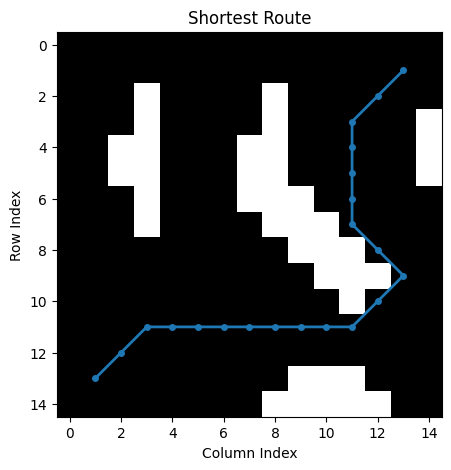

0.00017988972607241332


In [15]:
%matplotlib inline
import mpld3
import matplotlib.cm as cm
mpld3.disable_notebook()
dem = rio.open(filename)
slope_dem =dem.read(1)
fig, ax = plt.subplots(1, figsize=(5, 5))
ax.imshow(slope_dem, origin='upper', cmap='Greys_r', interpolation='none')
# Extract x, y coordinates for path plotting
path_x = [point[1] for point in formatted_path]  # Col indices
path_y = [point[0] for point in formatted_path]  # Row indices
# Plot path
plt.plot(path_x, path_y, marker='o', markersize=4, linewidth=2)
plt.title('Shortest Route')
total_trav_time = total_time_str
plt.xlabel('Column Index')
plt.ylabel('Row Index')
plt.grid(False)
plt.show()
print(total_trav_time/60)